# VISUALIZACIÓN DE DATOS BIOLÓGICOS
## ROBERTO THERÓN, 2026.
### EXPERTO EN BIOINFORMÁTICA Y GENÓMICA COMPUTACIONAL. UNIVERSIDAD DE SALAMANCA

## Introducción general del notebook

Bienvenido a este cuaderno didáctico, diseñado para el curso de 'Visualización de Datos Biológicos'. A lo largo de este material, exploraremos diversas técnicas y herramientas para la visualización efectiva de datos de expresión génica, un pilar fundamental en la bioinformática. Nuestro objetivo es no solo aprender a generar gráficos, sino a comprender cómo la elección de la herramienta y el enfoque didáctico pueden impactar la claridad y el mensaje de nuestra visualización. Realizaremos un proceso de mejora iterativa, comparando librerías como Altair, Plotly y Seaborn, para que puedas desarrollar un criterio sólido sobre cuándo y cómo aplicar cada una. ¡Prepárate para transformar datos complejos en narrativas visuales comprensibles!

Intriducción


## 1. Preparación del Entorno

### Configuración inicial: Importación de librerías y carga de datos

Para comenzar nuestro análisis y visualización de datos de expresión génica, primero necesitamos importar las librerías necesarias y cargar nuestro conjunto de datos.

#### Importación de Altair

`altair` es una librería declarativa para crear visualizaciones estadísticas en Python. Se basa en la 'Grammar of Graphics' y genera JSON de Vega-Lite, lo que facilita la creación de gráficos interactivos y adaptables a la web.

In [1]:
import altair as alt

#### Importación de Pandas

`pandas` es una librería fundamental para la manipulación y análisis de datos en Python. La usaremos para cargar y transformar nuestro conjunto de datos de expresión génica en un formato adecuado.

In [2]:
import pandas as pd

#### Carga del Conjunto de Datos

Cargamos el archivo CSV que contiene los datos de expresión génica. Este dataset incluye información sobre sujetos, tratamientos y niveles de expresión para varios genes.

In [3]:
df = pd.read_csv ('https://raw.githubusercontent.com/Robertotheron/biovis/refs/heads/main/Sesiones/ses_6/data/GSE68849-expression.csv') #https://jcoliver.github.io/learn-r/009-expression-heatmaps.html

In [4]:
df

,subject,treatment,IFNA5,IFNA13,IFNA2,SPIN1,ZNF451,IFNA16,RASSF1,IFNW1,MSR1,MIR1976
0,GSM1684095,control,83.12937,107.21900,195.1749,120.7922,569.3236,189.9071,352.9884,95.40194,107.02930,104.01750
1,GSM1684096,influenza,10096.47000,18974.16000,24029.1100,107.8756,432.3180,23060.4700,353.3666,8665.86600,108.82380,106.27090
2,GSM1684097,control,97.80374,128.01560,128.8408,126.9156,304.1524,170.2641,308.0817,96.96552,94.98350,82.84982
3,GSM1684098,influenza,8180.98900,15647.15000,23060.4700,123.5569,320.2590,21248.4400,267.4466,6903.48500,125.94200,108.88110
4,GSM1684099,control,81.70878,103.47340,100.7334,104.2249,270.9889,101.2051,308.7097,94.47841,104.55780,91.37495
5,GSM1684100,influenza,7054.90200,16991.39000,19282.9700,107.2359,300.7333,20424.6700,244.7788,5663.81600,96.96847,85.87805
6,GSM1684101,control,102.39670,120.65830,123.6374,122.6471,232.2481,155.0731,286.0506,103.61150,89.58318,120.63200
7,GSM1684102,influenza,15018.41000,18600.64000,20301.1400,117.9369,294.7462,17746.6300,386.8202,9198.55300,97.09310,86.59149
8,GSM1684103,control,78.12022,98.34311,111.5859,116.0432,327.0075,103.0275,352.3531,89.26273,119.65300,103.15130
9,GSM1684104,influenza,9397.26100,15403.11000,19136.4000,134.8029,287.4431,20583.4600,374.2139,7428.84900,89.70945,111.98500


#### Visualización inicial del DataFrame

Para entender la estructura y el contenido de nuestro conjunto de datos raw, mostramos las primeras filas del DataFrame. Observa que actualmente está en un formato 'ancho' donde cada gen es una columna.

Una versión 'tidy' (ordenada) de este conjunto de datos es aquella en la que los valores de expresión no serían encabezados de columna, sino valores en una columna de expresión. Para 'ordenar' este conjunto de datos, necesitamos 'derretirlo' (melt). La librería Pandas tiene una función incorporada que permite hacer precisamente eso. 'Despivota' un DataFrame de un formato 'ancho' a un formato 'largo'. Reutilizaremos esta función varias veces a lo largo del notebook.

In [8]:
formatted_df = pd.melt(df,
                       ["subject", "treatment"],
                       var_name="gene",
                       value_name="expression")
formatted_df = formatted_df.sort_values(by=["subject"])
formatted_df

,subject,treatment,gene,expression
0,GSM1684095,control,IFNA5,83.12937
80,GSM1684095,control,MSR1,107.02930
70,GSM1684095,control,IFNW1,95.40194
60,GSM1684095,control,RASSF1,352.98840
50,GSM1684095,control,IFNA16,189.90710
...,...,...,...,...
29,GSM1684104,influenza,IFNA2,19136.40000
19,GSM1684104,influenza,IFNA13,15403.11000
9,GSM1684104,influenza,IFNA5,9397.26100
89,GSM1684104,influenza,MSR1,89.70945


### 2. Introducción a Altair: Construyendo un Heatmap paso a paso

Comenzaremos a construir nuestro heatmap utilizando Altair, un enfoque declarativo que nos permite definir qué queremos visualizar de forma incremental. Cada paso nos acercará a un gráfico más informativo y comprensible.

#### Inicializando el Objeto Chart

Primero, creamos un objeto `Chart` de Altair a partir de nuestro `formatted_df`. Este objeto será la base para todas nuestras visualizaciones.

In [9]:
chart = alt.Chart(formatted_df)

#### Marca básica: Puntos

El `mark_point()` define que queremos representar cada fila de nuestro DataFrame como un punto. Por sí solo, sin codificación de ejes, no mostrará mucho, pero es el punto de partida para ver los datos.

In [10]:
chart.mark_point()

alt.Chart(...)

#### Codificando variables: Ejes X e Y

Ahora asignamos las columnas `subject` al eje X y `gene` al eje Y. El `:N` indica que son variables nominales (categóricas), lo que asegura que se traten como etiquetas discretas.

In [ ]:
chart.mark_point().encode(
    alt.X('subject:N'),
    alt.Y('gene:N')
)

alt.Chart(...)

#### Cambiando el tipo de marca: Rectángulos para un Heatmap

Para crear un heatmap, cambiamos el tipo de marca de `point` a `rect` (rectángulos). Esto crea una cuadrícula donde cada celda representará un sujeto y un gen específico.

In [11]:
chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N')
)

alt.Chart(...)

#### Añadiendo color: La expresión génica

El corazón del heatmap es la codificación del color. Aquí, asignamos la columna `expression` al canal de color (`alt.Color`). El `:Q` indica que `expression` es una variable cuantitativa. Altair asignará automáticamente un esquema de color predeterminado.

In [ ]:
chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N'),
    alt.Color('expression:Q')
)

alt.Chart(...)

## 2. Optimización iterativa del heatmap

Ahora que hemos creado un heatmap básico con Altair, es crucial entender que la visualización de datos es un proceso iterativo. Un "diseñador deliberado" no se conforma con la primera versión, sino que busca constantemente mejorar la claridad, el impacto y la interpretación de sus gráficos.

En esta sección, exploraremos cómo podemos refinar nuestro heatmap, paso a paso, aplicando principios de diseño y aprovechando las capacidades de Altair para comunicar mejor la información biológica.

Consideraremos aspectos como:

1.  **Escalas y Transformaciones**: La elección de una escala (lineal, logarítmica) y las transformaciones de datos pueden tener un impacto significativo en cómo se perciben los patrones.
2.  **Esquemas de Color**: La selección de una paleta de colores adecuada es fundamental para resaltar diferencias y grupos, y para asegurar la accesibilidad.
3.  **Interactividad**: Añadir herramientas de interactividad, como tooltips y selecciones, puede permitir a los usuarios explorar los datos en detalle.
4.  **Agrupación y Ordenación**: La forma en que se agrupan y ordenan los genes y sujetos puede revelar estructuras ocultas en los datos.

Reflexiona sobre el heatmap que acabas de generar. ¿Qué mejoras iniciales se te ocurren? ¿Hay algo que te confunda o que podría ser más claro?

#### Aplicando una escala logarítmica

Los datos de expresión génica a menudo tienen una distribución sesgada (algunos genes con valores muy altos, la mayoría con valores bajos). Una escala logarítmica (`scale=alt.Scale(type='log')`) es crucial para visualizar mejor las diferencias en los rangos inferiores de expresión y evitar que los valores extremos dominen la escala de color.

In [ ]:
chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N'),
    alt.Color('expression:Q',
              scale=alt.Scale(type='log')
    )
)

alt.Chart(...)

#### Añadiendo interactividad: Tooltips

Para hacer el heatmap más exploratorio, añadimos `tooltips`. Esto permite al usuario pasar el ratón sobre cada celda y ver los valores exactos de `subject`, `gene` y `expression`, mejorando la capacidad de investigar puntos de datos específicos.

In [ ]:
chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N'),
    alt.Color('expression:Q', scale=alt.Scale(type='log')),
    alt.Tooltip(['subject', 'gene', 'expression'])
)

alt.Chart(...)

#### Filtrando datos por grupo de tratamiento

Para comparar la expresión génica entre los grupos de control e influenza, creamos dos gráficos separados. Utilizamos `transform_filter` para seleccionar los datos de cada grupo. Esta es una forma eficaz de segmentar y comparar subconjuntos de datos.

In [ ]:
control=chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N'),
    alt.Color('expression:Q', scale=alt.Scale(type='log')),
    alt.Tooltip(['subject', 'gene', 'expression'])
).transform_filter('datum.treatment == "control"')

flu=chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N'),
    alt.Color('expression:Q', scale=alt.Scale(type='log')),
    alt.Tooltip(['subject', 'gene', 'expression'])
).transform_filter('datum.treatment != "control"')

#### Personalizando el esquema de color

La elección del esquema de color es vital para la interpretabilidad. Aquí, aplicamos el esquema de color `'yelloworangebrown'` (¡nota la importancia de la minúscula!). Altair ofrece una amplia gama de esquemas predefinidos, como los que se muestran en el listado a continuación.

In [ ]:
chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N'),
    alt.Color('expression:Q', scale=alt.Scale(type='log',scheme='yelloworangebrown')),
    alt.Tooltip(['subject', 'gene', 'expression'])
)

alt.Chart(...)

#### Otros ejemplos de esquemas de color

Para ilustrar la flexibilidad, probamos el mismo heatmap con un esquema de color diferente, `'yelloworangebrown'`, que puede ser más adecuado para ciertos tipos de datos o preferencias visuales.

#### Concatenando Múltiples gráficos

`control | flu` es la forma en Altair de concatenar horizontalmente dos gráficos. Esto nos permite ver los heatmaps de los grupos de control e influenza uno al lado del otro para una comparación directa.

Prueba estos esquemas de color
          "turbo",
          "viridis",
          "magma",
          "inferno",
          "plasma",
          "cividis",
          "darkblue",
          "darkgold",
          "darkgreen",
          "darkmulti",
          "DarkRed",
          "lightgreyred",
          "lightgreyteal",
          "lightmulti",
          "lightorange",
          "lighttealblue",
          "blues",
          "browns",
          "greens",
          "greys",
          "oranges",
          "purples",
          "reds",
          "tealblues",
          "teals",
          "warmgreys",
          "blueorange",
          "brownbluegreen",
          "purplegreen",
          "pinkyellowgreen",
          "purpleorange",
          "redblue",
          "redgrey",
          "redyellowblue",
          "redyellowgreen",
          "bluegreen",
          "bluepurple",
          "goldgreen",
          "goldorange",
          "goldred",
          "greenblue",
          "orangered",
          "purplebluegreen",
          "purpleblue",
          "purplered",
          "redpurple",
          "yellowgreenblue",
          "yellowgreen",
          "yelloworangbrown",
          "yelloworangered"

In [ ]:
chart.mark_rect().encode(
    alt.X('subject:N'),
    alt.Y('gene:N'),
    alt.Tooltip(['subject', 'gene', 'expression']),
    alt.Color('expression:Q', scale=alt.Scale(type='log',scheme='bluegreen'))
)

alt.Chart(...)

In [ ]:
control | flu

alt.HConcatChart(...)

## 3. Integrando Plotly: Heatmap interactivo de expresión génica

Plotly es una herramienta poderosa para crear visualizaciones interactivas. Ahora lo utilizaremos para generar un heatmap de nuestra expresión génica, demostrando cómo diferentes librerías pueden abordar la misma tarea con filosofías distintas.

#### Importación de Plotly Express y pivoteo de datos

Importamos `plotly.express` para una interfaz de alto nivel. Para `px.imshow`, a menudo necesitamos que los datos estén en formato 'ancho' (genes como filas, sujetos como columnas, expresiones como valores), por lo que usamos `pivot_table`.

### Transformación de Formato 'Largo' a 'Ancho'

El `formatted_df` que hemos estado utilizando está en un formato 'largo' o 'tidy', donde cada fila representa una observación (sujeto, gen, expresión). Para crear un heatmap con `plotly.express.imshow` (y muchas otras funciones de visualización de calor), a menudo es más conveniente tener los datos en un formato 'ancho', donde:

*   Cada fila corresponde a una variable (en este caso, un `gene`).
*   Cada columna corresponde a otra variable (en este caso, un `subject`).
*   Las celdas contienen los valores de la medida (la `expression`).

Esta reestructuración se conoce como 'pivoteo' y se realiza utilizando la función `pivot_table` de Pandas. Esto nos permite pasar de tener las expresiones como una columna a tenerlas como los valores de una matriz, con genes y sujetos como índices.

In [ ]:
import plotly.express as px

# Pivotear formatted_df para el heatmap de Plotly
# genes como filas, subjects como columnas, expresión como valores
expression_pivot = formatted_df.pivot_table(index='gene', columns='subject', values='expression')

# Crear el heatmap con Plotly
fig = px.imshow(expression_pivot,
                labels=dict(x="Sujeto", y="Gen", color="Expresión"),
                x=expression_pivot.columns,
                y=expression_pivot.index,
                title='Heatmap de Expresión Génica con Plotly',
                color_continuous_scale='Viridis') # Puedes experimentar con otros esquemas de color aquí

fig.show()

## 4. Exploración con Seaborn: Clustermaps para agrupación de datos

Seaborn es una librería de visualización estadística basada en Matplotlib. Es particularmente útil para crear gráficos complejos como los `clustermaps`, que nos permiten visualizar no solo los datos sino también sus relaciones de agrupamiento.

#### Importación de Seaborn y Matplotlib

Importamos `seaborn` (comúnmente como `sns`) y `matplotlib.pyplot` (comúnmente como `plt`) para tener acceso a sus funciones de trazado.

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

#### Recargando y Preparando Datos para Seaborn

Para el `clustermap` de Seaborn, es más conveniente trabajar con el DataFrame original en formato 'ancho', donde los sujetos son el índice. Recargamos los datos y configuramos `subject` como índice.

In [ ]:
df = pd.read_csv ('https://raw.githubusercontent.com/Robertotheron/biovis/refs/heads/main/Sesiones/ses_6/data/GSE68849-expression.csv')
df = df.set_index('subject')
df

,treatment,IFNA5,IFNA13,IFNA2,SPIN1,ZNF451,IFNA16,RASSF1,IFNW1,MSR1,MIR1976
subject,,,,,,,,,,,
GSM1684095,control,83.12937,107.21900,195.1749,120.7922,569.3236,189.9071,352.9884,95.40194,107.02930,104.01750
GSM1684096,influenza,10096.47000,18974.16000,24029.1100,107.8756,432.3180,23060.4700,353.3666,8665.86600,108.82380,106.27090
GSM1684097,control,97.80374,128.01560,128.8408,126.9156,304.1524,170.2641,308.0817,96.96552,94.98350,82.84982
GSM1684098,influenza,8180.98900,15647.15000,23060.4700,123.5569,320.2590,21248.4400,267.4466,6903.48500,125.94200,108.88110
GSM1684099,control,81.70878,103.47340,100.7334,104.2249,270.9889,101.2051,308.7097,94.47841,104.55780,91.37495
GSM1684100,influenza,7054.90200,16991.39000,19282.9700,107.2359,300.7333,20424.6700,244.7788,5663.81600,96.96847,85.87805
GSM1684101,control,102.39670,120.65830,123.6374,122.6471,232.2481,155.0731,286.0506,103.61150,89.58318,120.63200
GSM1684102,influenza,15018.41000,18600.64000,20301.1400,117.9369,294.7462,17746.6300,386.8202,9198.55300,97.09310,86.59149
GSM1684103,control,78.12022,98.34311,111.5859,116.0432,327.0075,103.0275,352.3531,89.26273,119.65300,103.15130


#### Codificando la Variable Categórica 'treatment'

Para que Seaborn pueda usar la columna 'treatment' en ciertos cálculos o visualizaciones (como la barra lateral de color para el tratamiento), la convertimos de una etiqueta categórica ('control', 'influenza') a valores numéricos (0, 1).

In [ ]:
df['treatment'] = ([0 if x == 'control' else 1 for x in df['treatment']])
df

,treatment,IFNA5,IFNA13,IFNA2,SPIN1,ZNF451,IFNA16,RASSF1,IFNW1,MSR1,MIR1976
subject,,,,,,,,,,,
GSM1684095,0,83.12937,107.21900,195.1749,120.7922,569.3236,189.9071,352.9884,95.40194,107.02930,104.01750
GSM1684096,1,10096.47000,18974.16000,24029.1100,107.8756,432.3180,23060.4700,353.3666,8665.86600,108.82380,106.27090
GSM1684097,0,97.80374,128.01560,128.8408,126.9156,304.1524,170.2641,308.0817,96.96552,94.98350,82.84982
GSM1684098,1,8180.98900,15647.15000,23060.4700,123.5569,320.2590,21248.4400,267.4466,6903.48500,125.94200,108.88110
GSM1684099,0,81.70878,103.47340,100.7334,104.2249,270.9889,101.2051,308.7097,94.47841,104.55780,91.37495
GSM1684100,1,7054.90200,16991.39000,19282.9700,107.2359,300.7333,20424.6700,244.7788,5663.81600,96.96847,85.87805
GSM1684101,0,102.39670,120.65830,123.6374,122.6471,232.2481,155.0731,286.0506,103.61150,89.58318,120.63200
GSM1684102,1,15018.41000,18600.64000,20301.1400,117.9369,294.7462,17746.6300,386.8202,9198.55300,97.09310,86.59149
GSM1684103,0,78.12022,98.34311,111.5859,116.0432,327.0075,103.0275,352.3531,89.26273,119.65300,103.15130


#### Clustermap por Defecto

Aquí creamos un `clustermap` básico. Por defecto, Seaborn realiza un clustering jerárquico tanto en las filas (genes) como en las columnas (sujetos) y muestra dendrogramas que ilustran las relaciones de agrupamiento.

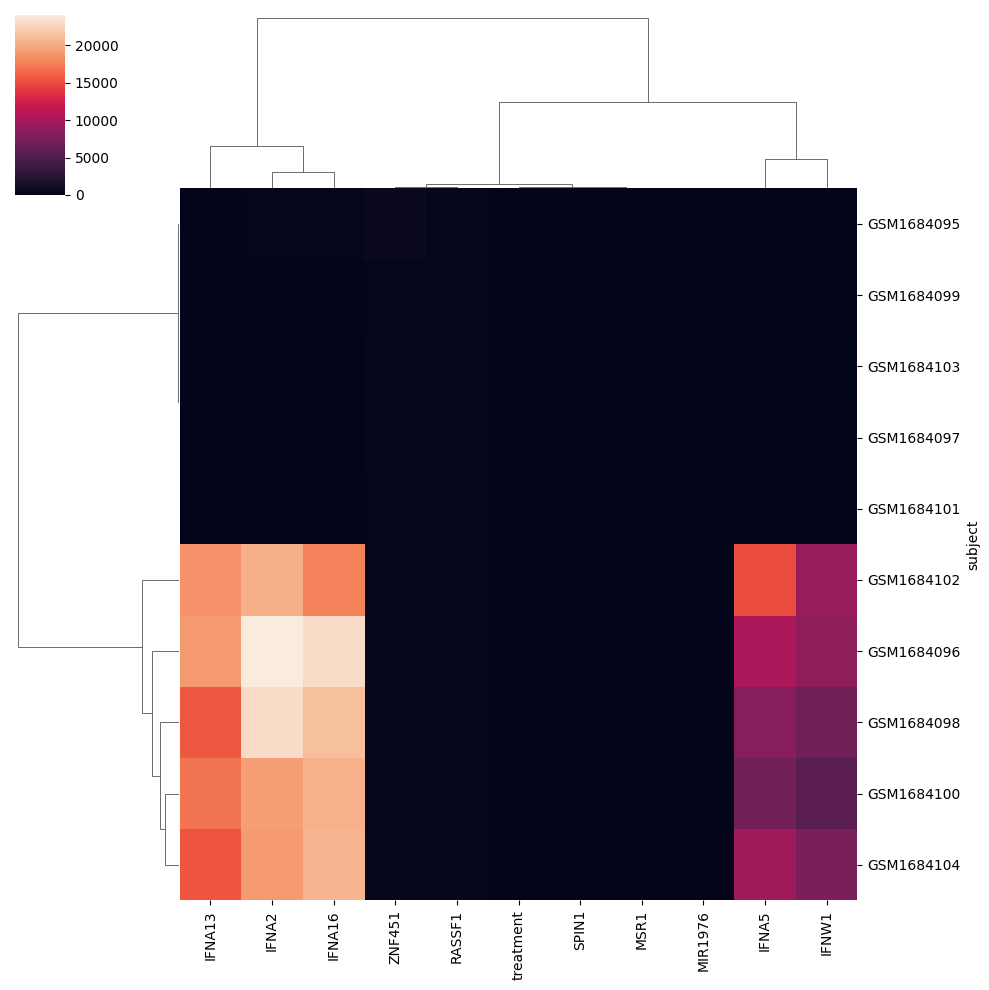

In [ ]:
# Default plot
sns.clustermap(df)

#### Estandarización de Datos (`standard_scale=1`)

La estandarización (escalar los valores para que cada fila tenga media 0 y desviación estándar 1) es a menudo crucial antes del clustering. `standard_scale=1` aplica esta transformación a las filas (genes), haciendo que la variabilidad de cada gen contribuya equitativamente a la distancia.

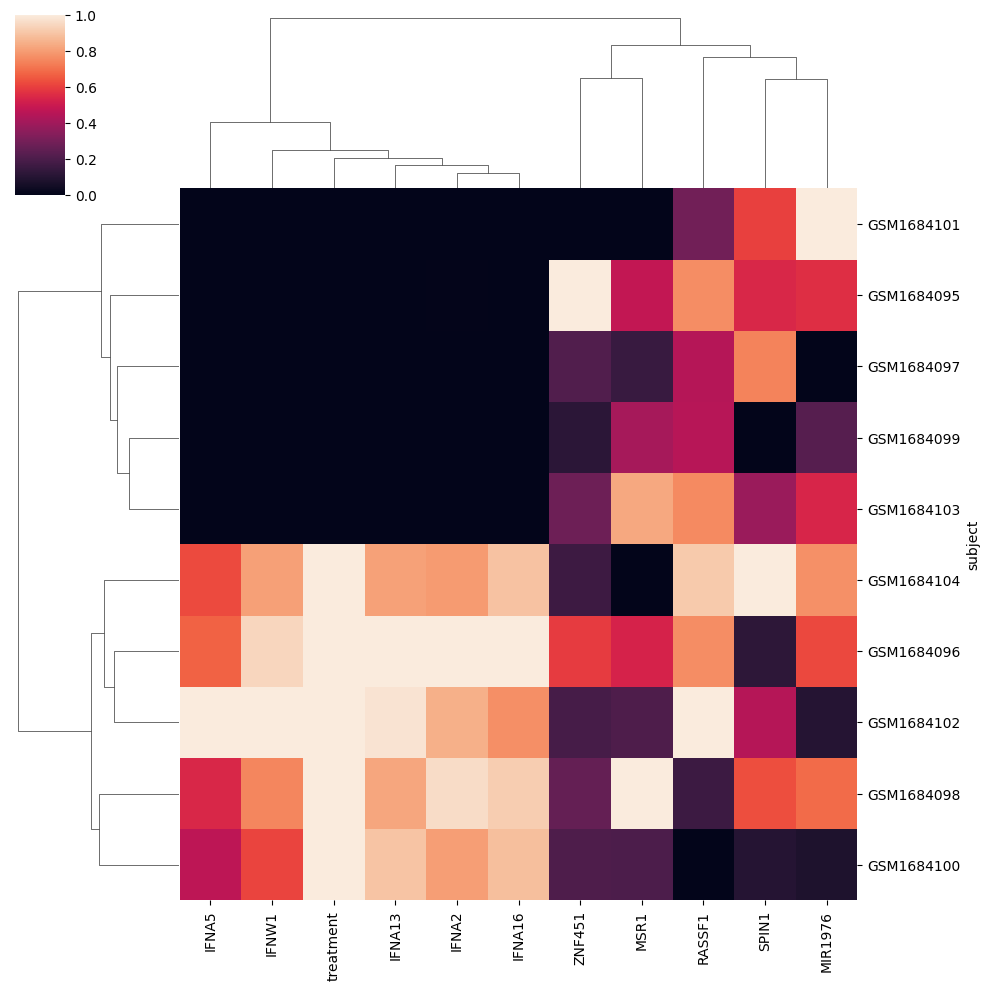

In [ ]:
# Standardize:
sns.clustermap(df, standard_scale=1)

#### Normalización Z-Score (`z_score=1`)

De manera similar, `z_score=1` aplica la normalización Z-score a través de las filas. Esta es otra forma de escalar los datos que puede ser útil dependiendo de la naturaleza de la distribución de expresión génica.

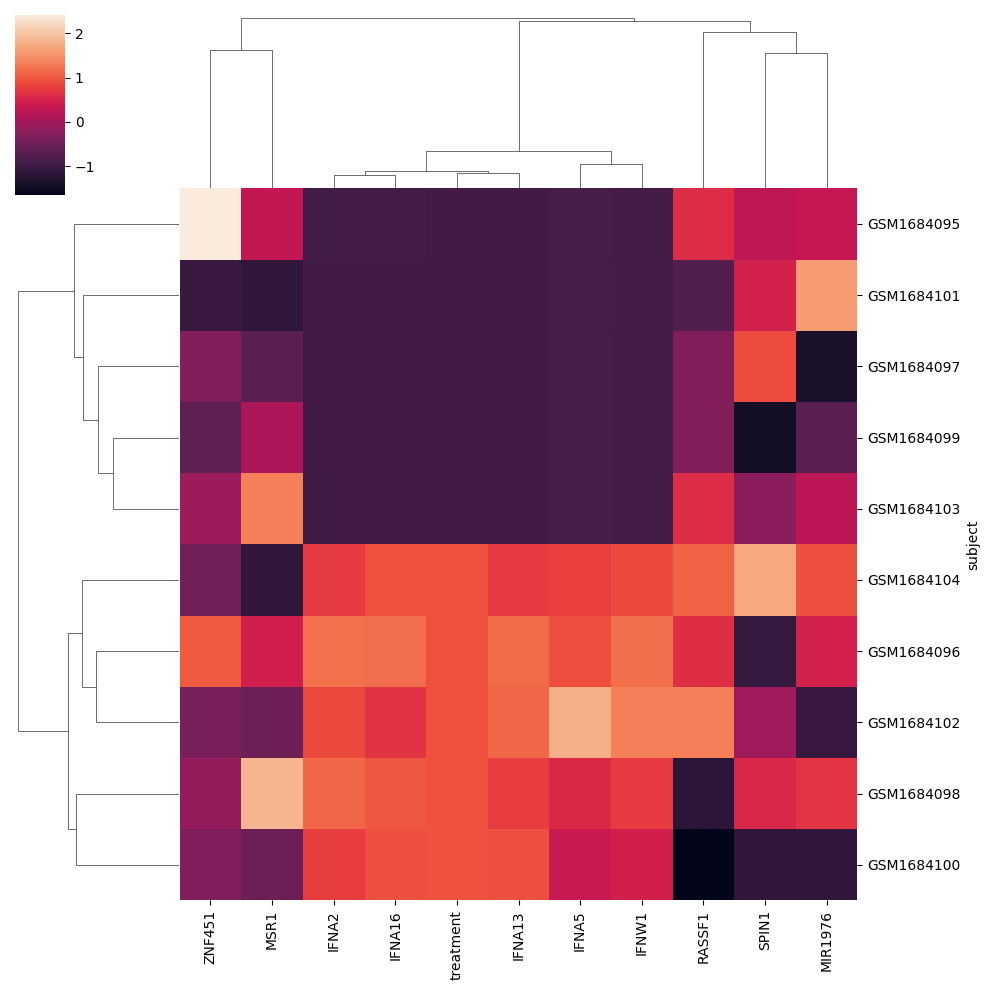

In [ ]:
# Normalize
sns.clustermap(df, z_score=1)

#### Usando la Distancia de Correlación (`metric="correlation"`)

El parámetro `metric` en `clustermap` define cómo se calcula la distancia entre los elementos para el clustering. La distancia de correlación (`"correlation"`) es común para datos biológicos, ya que agrupa elementos con patrones de expresión similares, independientemente de la magnitud absoluta.

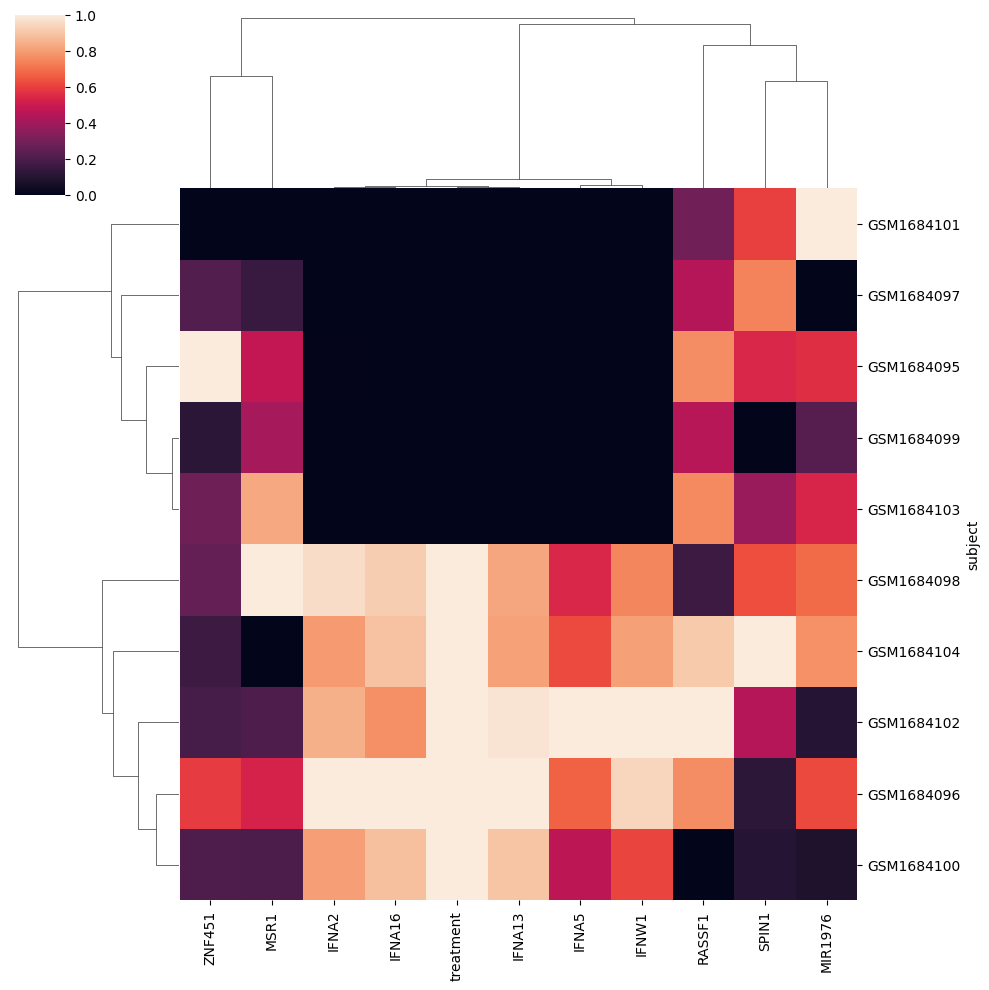

In [ ]:
# plot with correlation distance
sns.clustermap(df, metric="correlation", standard_scale=1)

#### Usando la Distancia Euclidiana (`metric="euclidean"`)

La distancia euclidiana es otra métrica común que mide la distancia geométrica directa entre los puntos de datos. Es sensible a la magnitud de las diferencias y puede ser útil en otros contextos.

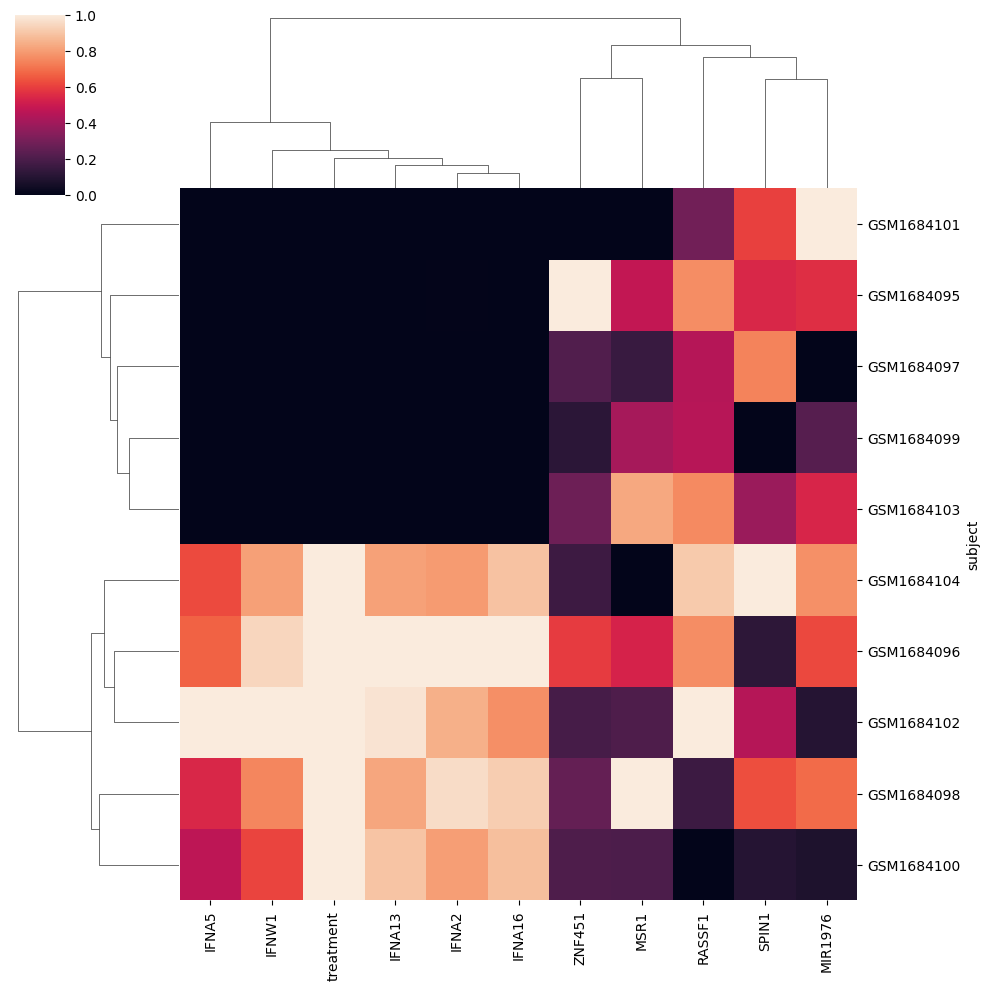

In [ ]:
# plot with euclidean distance
sns.clustermap(df, metric="euclidean", standard_scale=1)

#### Método de Enlace: 'Single' (`method="single"`)

El parámetro `method` determina el algoritmo de enlace utilizado para construir el clustering jerárquico. El método 'single' une los dos clústeres más cercanos basándose en la distancia mínima entre cualquier par de puntos de los clústeres.

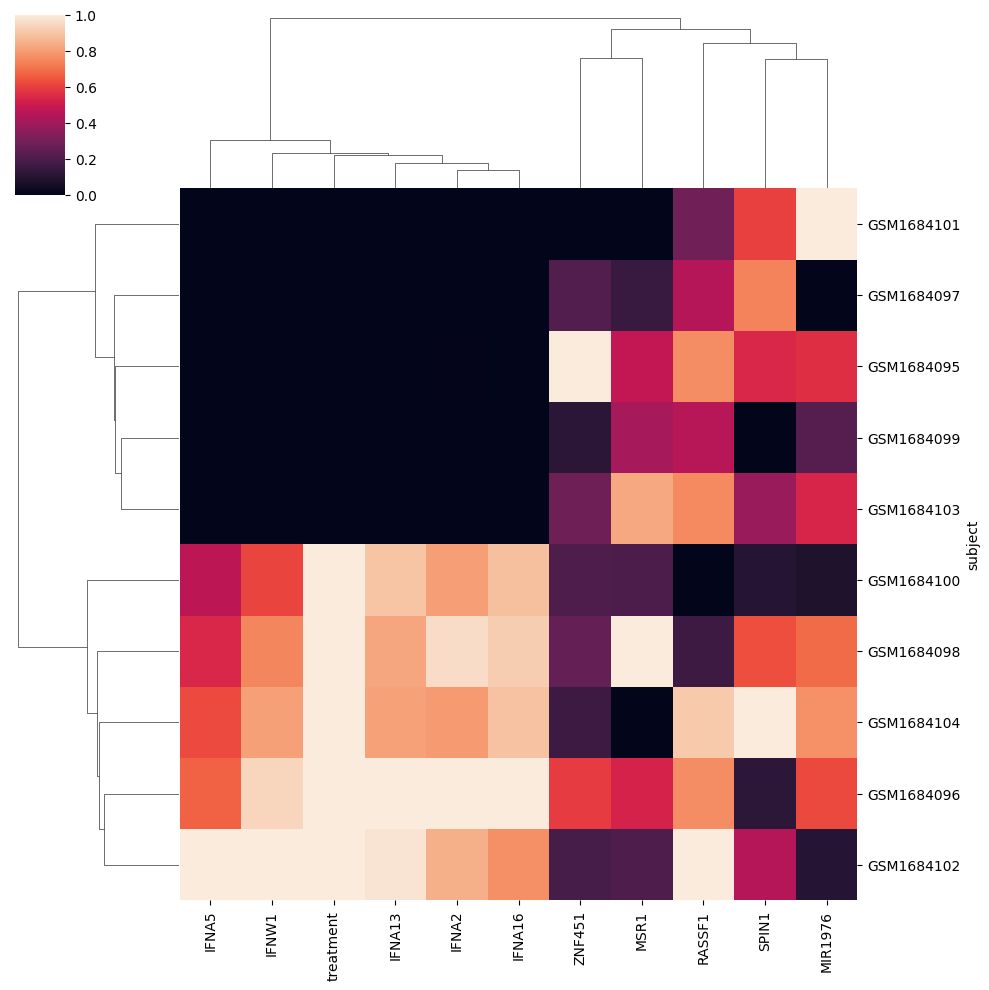

In [ ]:
# linkage method to use for calculating clusters: single
sns.clustermap(df, metric="euclidean", standard_scale=1, method="single")

#### Método de Enlace: 'Ward' (`method="ward"`)

El método 'ward' busca minimizar la varianza dentro de cada clúster al unirlos. Es uno de los métodos más populares para el clustering jerárquico y a menudo produce clústeres bien definidos.

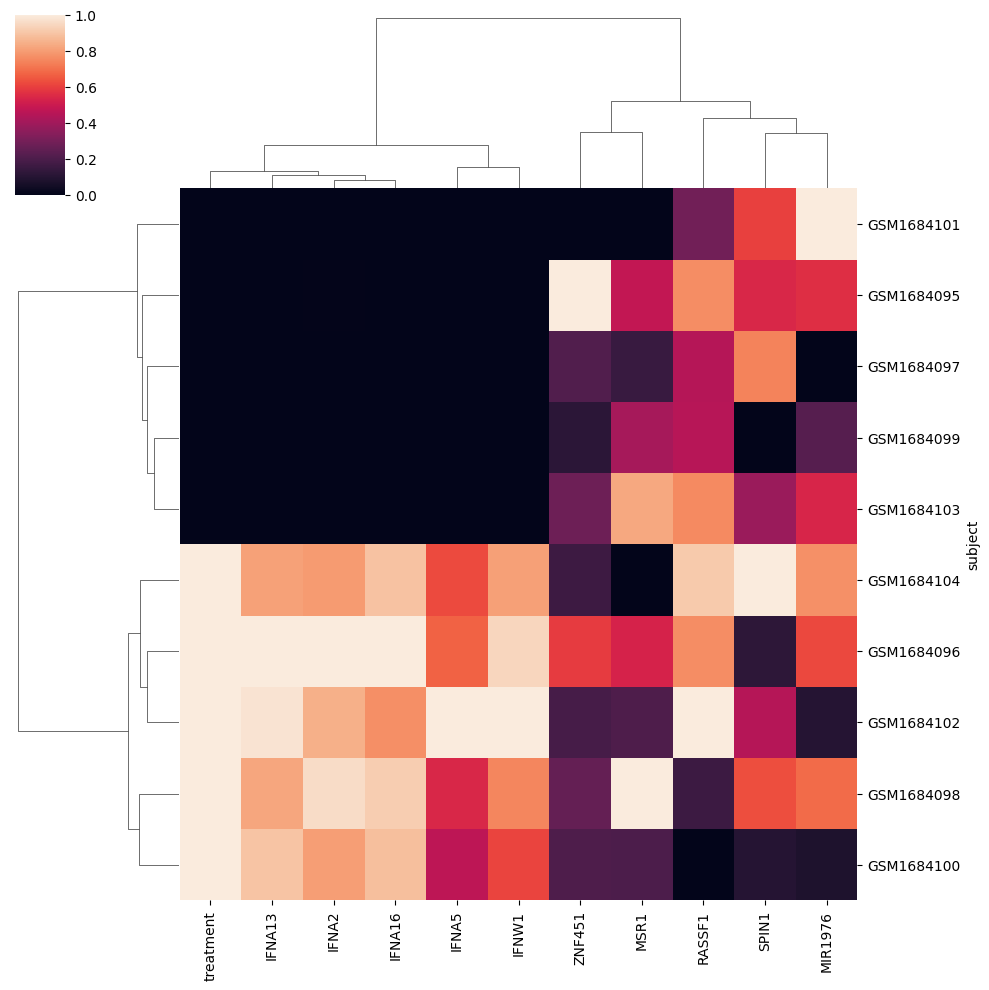

In [ ]:
# linkage method to use for calculating clusters: ward
sns.clustermap(df, metric="euclidean", standard_scale=1, method="ward")

#### Cambiando la Paleta de Color: 'Mako' (`cmap="mako"`)

Al igual que en Altair, podemos personalizar la paleta de colores (`cmap`) del heatmap en Seaborn para mejorar la estética o resaltar ciertos patrones. 'mako' es una paleta secuencial.

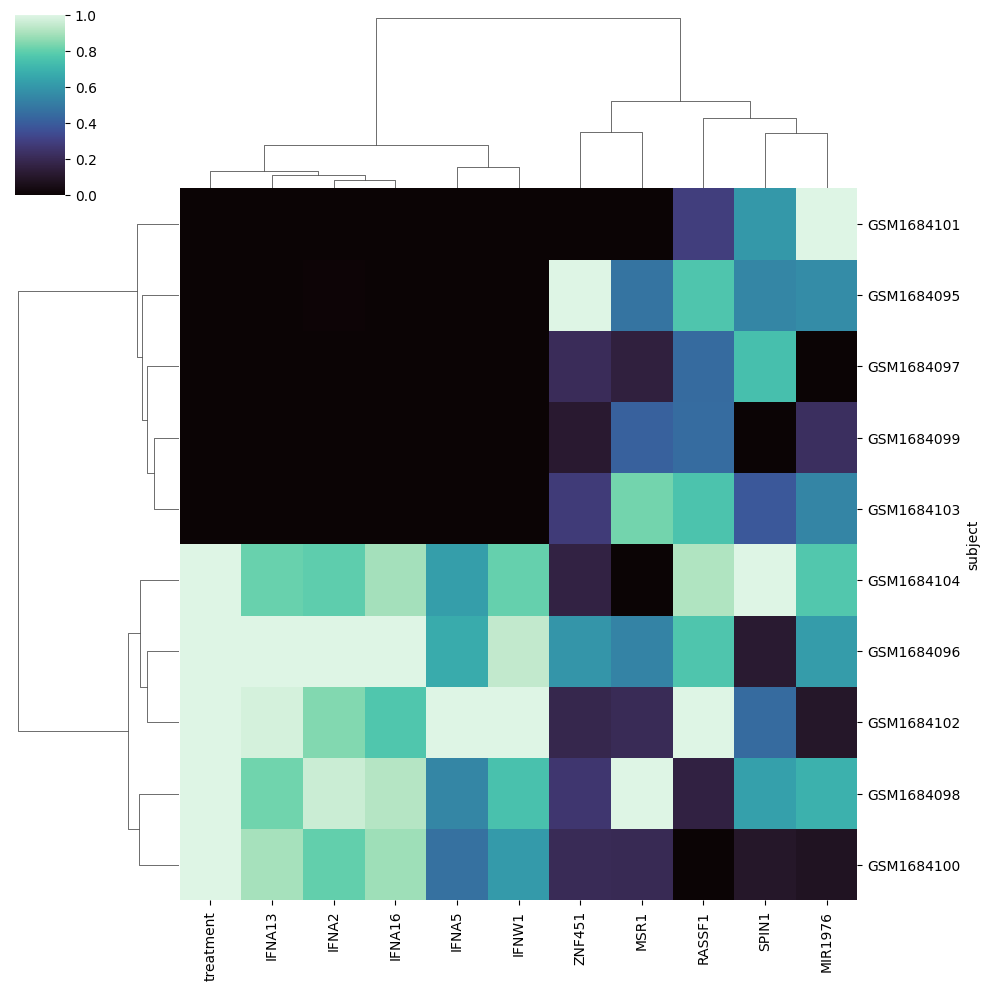

In [ ]:
# Change color palette
sns.clustermap(df, metric="euclidean", standard_scale=1, method="ward", cmap="mako")

#### Cambiando la Paleta de Color: 'Viridis' (`cmap="viridis"`)

'Viridis' es una paleta perceptualmente uniforme y adecuada para personas con daltonismo, lo que la convierte en una excelente opción para visualizaciones científicas.

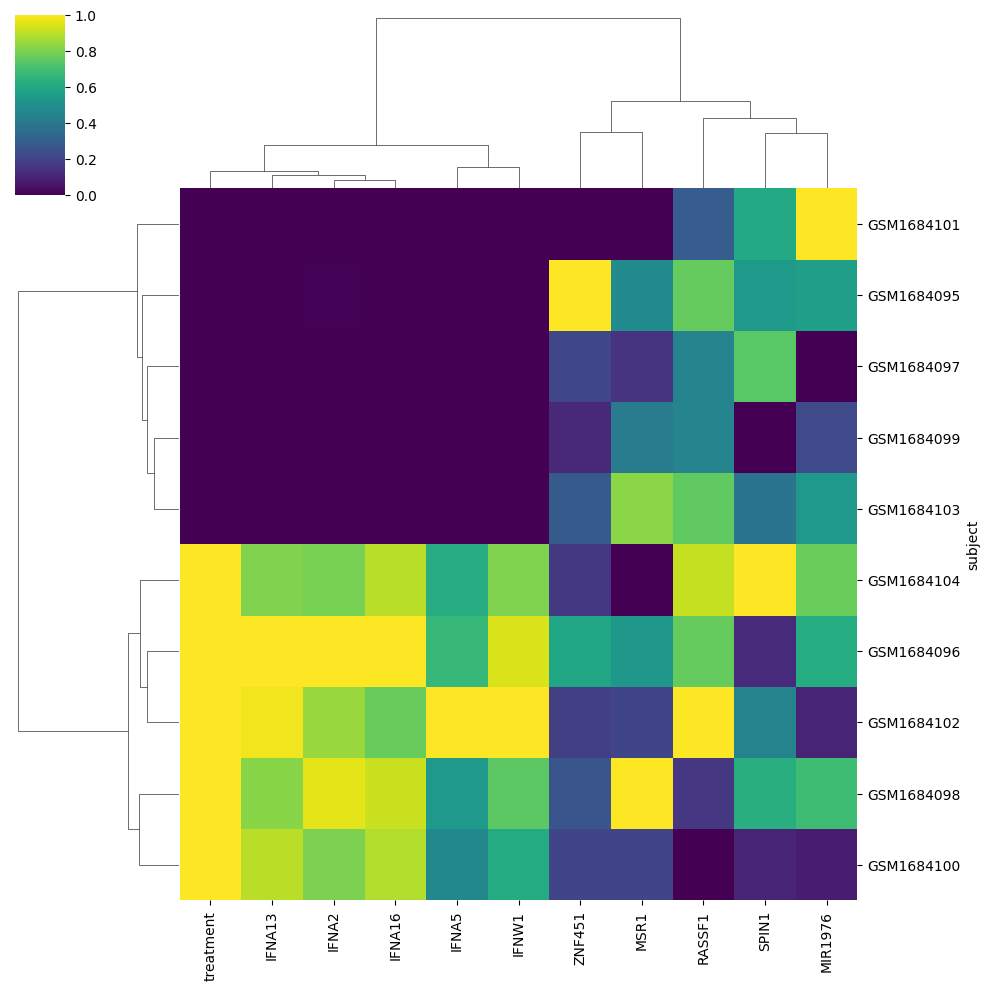

In [ ]:
sns.clustermap(df, metric="euclidean", standard_scale=1, method="ward", cmap="viridis")


#### Cambiando la Paleta de Color: 'Blues' (`cmap="Blues"`)

'Blues' es otra paleta secuencial, útil cuando se quiere representar un gradiente de valores de bajos a altos utilizando tonos de azul.

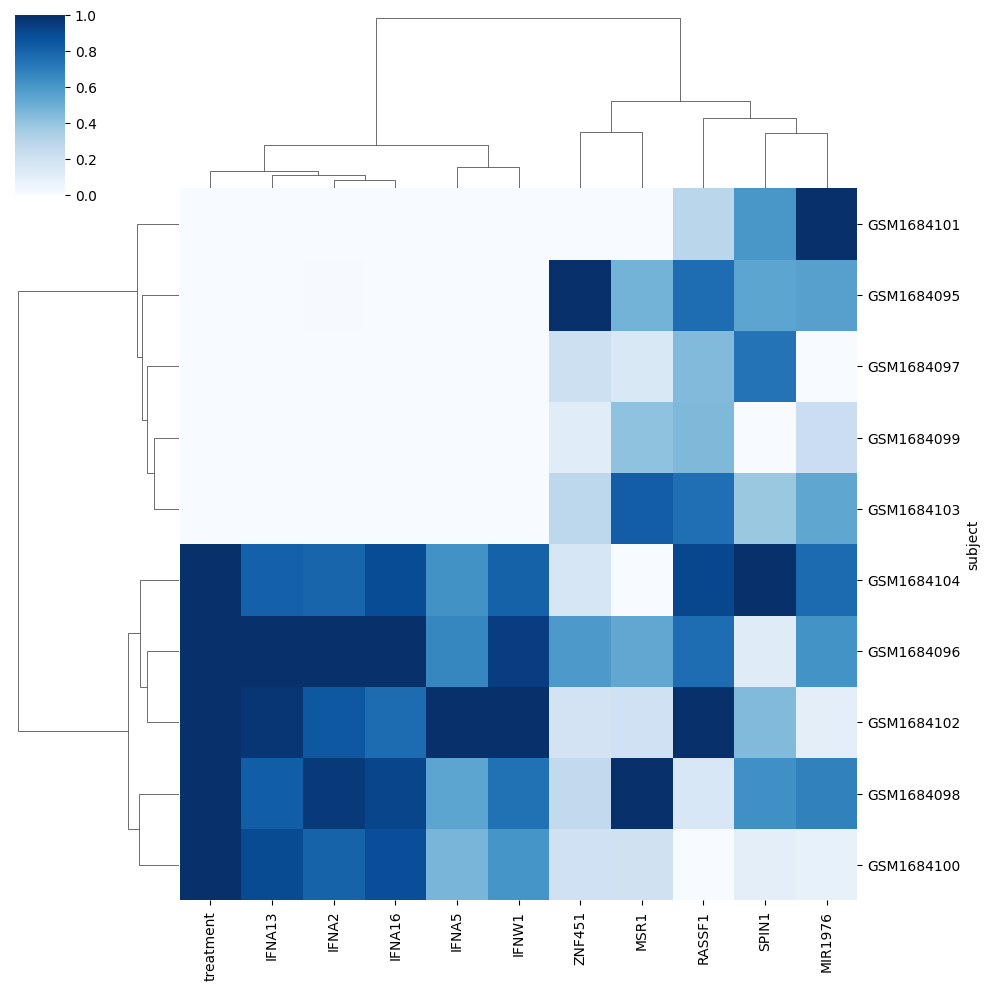

In [ ]:
sns.clustermap(df, metric="euclidean", standard_scale=1, method="ward", cmap="Blues")

#### Extrayendo Información del Dendrograma

Seaborn permite acceder a la estructura de los dendrogramas generados por `clustermap`. Aquí, importamos `numpy` y extraemos las coordenadas `dcoord` e `icoord` del dendrograma de columnas para un análisis más detallado si fuera necesario.

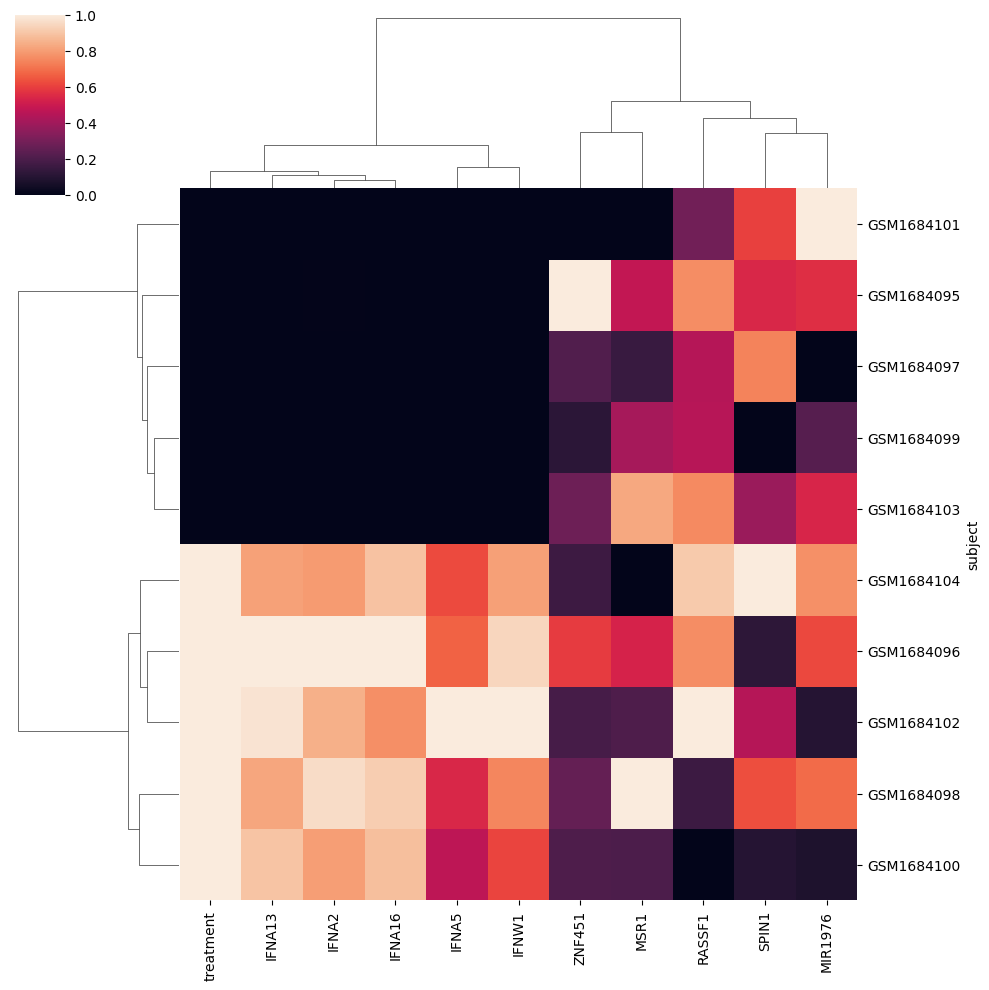

In [ ]:
import numpy as np
tree = sns.clustermap(df, metric="euclidean", standard_scale=1, method="ward")
dgram = tree.dendrogram_col.dendrogram
D = np.array(dgram['dcoord'])
I = np.array(dgram['icoord'])

### `Seaborn.clustermap` vs. `Plotly.express.imshow`

Aunque ambos pueden crear heatmaps, `seaborn.clustermap` y `plotly.express.imshow` están diseñados con propósitos y filosofías ligeramente diferentes, lo que los hace adecuados para distintos casos de uso.

#### **`Seaborn.clustermap`**

*   **Propósito Principal**: `clustermap` está diseñado específicamente para la visualización de datos donde la **agrupación jerárquica (clustering)** es de interés. Su objetivo es reorganizar las filas y/o columnas de una matriz de datos para mostrar patrones de similitud o disimilitud, acompañándolos con dendrogramas.
*   **Características Clave**:
    *   **Clustering Integrado**: Realiza un clustering jerárquico de filas y columnas por defecto, mostrando los dendrogramas resultantes, lo cual es fundamental en análisis ómicos (genómica, proteómica).
    *   **Ordenación por Similitud**: Reordena automáticamente los datos para agrupar elementos similares, haciendo que los patrones sean más evidentes visualmente.
    *   **Escalado y Normalización**: Ofrece opciones convenientes para estandarizar o normalizar los datos antes del clustering y la visualización (`standard_scale`, `z_score`).
    *   **Estático**: Genera gráficos estáticos (basados en Matplotlib), aunque de alta calidad para publicaciones.
*   **Caso de Uso Típico**: Análisis de expresión génica para identificar grupos de genes con patrones de expresión similares o grupos de muestras con perfiles moleculares parecidos. Es una herramienta esencial en bioinformática para la exploración inicial de grandes matrices de datos.

#### **`Plotly.express.imshow`**

*   **Propósito Principal**: `imshow` (de *image show*) en Plotly está diseñado para visualizar **matrices de datos de forma interactiva**, similar a una imagen. Se enfoca en la representación visual directa de la matriz y en la interactividad.
*   **Características Clave**:
    *   **Interactividad**: Ofrece funcionalidades interactivas (zoom, pan, tooltips) por defecto, lo que permite una exploración detallada de los valores de la matriz.
    *   **Representación Directa**: Simplemente muestra la matriz tal como está, sin realizar clustering o reordenación automática. La ordenación debe realizarse previamente en el DataFrame si es deseada.
    *   **Flexibilidad**: Es muy flexible para mostrar cualquier matriz numérica. Puede ser utilizado para representar imágenes, matrices de correlación, o heatmaps de datos pre-ordenados.
    *   **Web-Orientado**: Los gráficos son interactivos en entornos web (Jupyter notebooks, Dash apps).
*   **Caso de Uso Típico**: Visualización interactiva de matrices de correlación, mapas de contacto de proteínas, o matrices de datos que ya han sido ordenadas por otros algoritmos y se busca una visualización interactiva y exploratoria de los valores.

#### **En Resumen**

*   Si tu objetivo principal es **descubrir patrones de agrupación inherentes en tus datos** y visualizarlos junto con la estructura de clustering, **`seaborn.clustermap`** es la herramienta más adecuada.
*   Si ya tienes una **matriz de datos (potencialmente ya ordenada) y deseas una visualización interactiva y exploratoria de sus valores**, donde el clustering no es el foco principal o ya se ha realizado, entonces **`plotly.express.imshow`** es una excelente elección.

## 5. Comparando herramientas de visualización: Altair, Seaborn y Plotly

Como hemos visto, existen múltiples herramientas poderosas para la visualización de datos en Python, cada una con sus propias fortalezas y casos de uso óptimos. Aquí presentamos una comparación para ayudaros a decidir cuándo usar cada una:

### Altair (Grammar of Graphics para Vega-Lite)

*   **Ventajas:**
    *   **Declarativo y Robusto**: Permite crear visualizaciones complejas con un código conciso, siguiendo la "Grammar of Graphics". Te enfocas en *qué* quieres mostrar, no en *cómo* dibujarlo.
    *   **Interactividad Nታativa**: Facilita la creación de gráficos interactivos (zoom, pan, tooltips, selección) con poco esfuerzo.
    *   **JSON Subyacente (Vega-Lite)**: Genera especificaciones JSON de Vega-Lite, lo que hace que los gráficos sean muy portables y aptos para la web. Ideal para dashboards y aplicaciones web.
    *   **Perfecto para Exploración**: Su naturaleza declarativa y la interactividad lo hacen excelente para la exploración inicial y la creación rápida de prototipos.
    *   **Limpieza y Consistencia**: Fomenta gráficos visualmente limpios y estéticamente agradables por defecto.
*   **Consideraciones:**
    *   Puede ser menos flexible para gráficos altamente personalizados o visualizaciones 3D complejas.
    *   No está diseñado para conjuntos de datos extremadamente grandes en el cliente (aunque puede manejar grandes datasets en el servidor).

### Seaborn (Estadísticas y Estética sobre Matplotlib)

*   **Ventajas:**
    *   **Orientado a Estadísticas**: Diseñado para crear visualizaciones estadísticas informativas y atractivas con facilidad. Excelente para explorar relaciones entre variables y distribuciones.
    *   **Integración con Pandas**: Funciona muy bien con DataFrames de Pandas.
    *   **Amplia Gama de Gráficos Estadísticos**: Ofrece funciones de alto nivel para box plots, violin plots, pair plots, y, como hemos visto, `clustermap` para heatmaps con dendrogramas.
    *   **Basado en Matplotlib**: Esto significa que puedes usar toda la potencia y flexibilidad de Matplotlib para personalizar aún más los gráficos de Seaborn.
*   **Consideraciones:**
    *   Menos interactividad nativa que Altair o Plotly.
    *   Los gráficos pueden requerir más ajuste manual para un aspecto pulido si no se usan los estilos por defecto.
    *   Puede ser más verboso para crear gráficos complejos de múltiples capas en comparación con Altair.

### Plotly (Interactividad Avanzada y Gráficos 3D)

*   **Ventajas:**
    *   **Interactividad Avanzada**: Ofrece interactividad de primera clase (zoom, pan, hover, selección) directamente en el navegador, incluso sin configuraciones adicionales.
    *   **Gráficos 3D y Científicos**: Excelente para visualizaciones 3D, gráficos de superficie, y visualizaciones científicas especializadas, lo cual es muy relevante en bioinformática (ej. estructuras proteicas, mallas genómicas).
    *   **Dashboards (Dash)**: Es la base de Dash, una biblioteca para construir dashboards interactivos directamente en Python.
    *   **Múltiples Lenguajes**: Disponible en Python, R, JavaScript, etc., lo que lo hace versátil en entornos multidisciplinares.
    *   **Calidad de Publicación**: Sus gráficos son de alta calidad y aptos para publicaciones.
*   **Consideraciones:**
    *   Puede ser más verboso que Altair para gráficos simples.
    *   La curva de aprendizaje puede ser un poco más pronunciada para usuarios nuevos debido a la cantidad de opciones y la estructura de objetos de gráficos.
    *   Los gráficos pueden tener un tamaño de archivo más grande debido a la incrustación de JavaScript.

**En resumen**: Utiliza **Altair** para exploraciones rápidas y gráficos interactivos web. Elige **Seaborn** para análisis estadísticos profundos y gráficos de publicación de alta calidad (especialmente con personalización de Matplotlib). Y recurre a **Plotly** cuando la interactividad avanzada, los gráficos 3D o la creación de dashboards sean tus principales requisitos. La elección de la herramienta dependerá siempre del tipo de datos, el mensaje que quieres comunicar y el nivel de interactividad deseado.

### Comparación de Rendimiento y Legibilidad: Seaborn vs. Plotly para Heatmaps

Ahora que hemos visto cómo crear heatmaps tanto con Plotly (utilizando `imshow` en el formato 'ancho') como con Seaborn (que suele trabajar con un formato 'ancho' por defecto para `clustermap`), es útil comparar su rendimiento y la legibilidad del código desde una perspectiva didáctica.

#### **Legibilidad del Código:**

*   **Plotly (`px.imshow`)**: El código para `px.imshow` es generalmente muy legible y directo. Una vez que los datos están en el formato 'ancho' correcto, la llamada a la función es bastante intuitiva, con argumentos claros para los ejes x, y, y el color. La personalización se realiza a través de argumentos en la función o manipulando el objeto `fig` resultante.

    ```python
    # Ejemplo de Plotly (simplificado)
    fig = px.imshow(expression_pivot,
                    labels=dict(x="Sujeto", y="Gen", color="Expresión"),
                    x=expression_pivot.columns,
                    y=expression_pivot.index,
                    title='Heatmap de Expresión Génica con Plotly')
    ```

*   **Seaborn (`sns.clustermap`)**: Seaborn es conocido por su sintaxis de alto nivel para gráficos estadísticos, lo que también contribuye a la legibilidad. Para `clustermap`, el código es conciso, especialmente si los datos ya están en un formato adecuado (índice para filas, columnas para columnas). Los parámetros para la agrupación y el escalado son claros.

    ```python
    # Ejemplo de Seaborn (simplificado)
    sns.clustermap(df, metric="euclidean", standard_scale=1, method="ward", cmap="viridis")
    ```

    **Conclusión sobre Legibilidad**: Ambos son altamente legibles para sus respectivos propósitos. Plotly es más explícito en la asignación de ejes, mientras que Seaborn es más conciso para la funcionalidad de clustering que ofrece.

#### **Rendimiento:**

El "rendimiento" puede referirse a varios aspectos: velocidad de ejecución, eficiencia de memoria, o incluso el rendimiento interactivo en el navegador.

*   **Velocidad de Ejecución (Generación del Gráfico)**:
    *   Para conjuntos de datos pequeños a medianos, las diferencias de velocidad entre Plotly y Seaborn (que se basa en Matplotlib) suelen ser insignificantes. Ambas bibliotecas están bien optimizadas.
    *   Para conjuntos de datos muy grandes (miles o decenas de miles de filas/columnas), Plotly puede ser marginalmente más lento en la *generación inicial* del gráfico en Python, ya que crea una estructura de datos JSON más compleja para la interactividad web. Sin embargo, la renderización en el navegador es muy eficiente.

*   **Eficiencia de Memoria**: Ambas bibliotecas son razonablemente eficientes en memoria. El factor limitante suele ser el tamaño del DataFrame de Pandas subyacente.

*   **Rendimiento Interactivo (en el navegador)**:
    *   **Plotly**: Brilla aquí. Sus gráficos están diseñados para la interactividad web. Incluso con datasets grandes, el zoom, pan, tooltips y selecciones son fluidos, ya que la lógica interactiva se maneja eficientemente en JavaScript en el cliente. Esto es una gran ventaja para la exploración interactiva de datos.
    *   **Seaborn**: Como se basa en Matplotlib, sus gráficos son estáticos por defecto. Aunque se pueden añadir algunas funcionalidades interactivas con bibliotecas como `mpld3` o `plotly.tools.mpl_to_plotly`, no es su punto fuerte principal y el rendimiento interactivo nativo no se compara con Plotly.

**Conclusión sobre Rendimiento**: Plotly ofrece un rendimiento interactivo superior en el navegador, lo cual es crucial para la exploración de datos biológicos complejos. La generación inicial de gráficos es comparable para la mayoría de los casos de uso.

## 6. Coordenadas Paralelas con Plotly: Visualizando múltiples dimensiones

Las Coordenadas Paralelas son una poderosa herramienta para visualizar datos multivariados. En lugar de proyectar todos los datos en un espacio 2D o 3D, cada variable se representa como un eje vertical paralelo, y cada observación (en nuestro caso, cada sujeto) se dibuja como una línea que conecta los valores en cada eje. Esto nos permite identificar patrones, relaciones y anomalías en un conjunto de datos complejos.

### ¿Por qué Coordenadas Paralelas?

*   **Exploración de relaciones**: Permiten ver cómo se comportan múltiples variables simultáneamente para cada observación. Las líneas que se agrupan o cruzan revelan patrones interesantes.
*   **Identificación de clusters**: Es posible visualizar grupos de observaciones que comparten características similares a través de las diferentes dimensiones.
*   **Detección de outliers**: Las líneas que se desvían significativamente del resto pueden indicar observaciones atípicas.

### Implementación con `plotly.express`

`plotly.express.parallel_coordinates` simplifica enormemente la creación de estos gráficos interactivos. Para nuestro conjunto de datos de expresión génica, utilizaremos esta función para visualizar los niveles de expresión de diferentes genes (dimensiones) para cada sujeto, coloreando las líneas según el grupo de tratamiento (`control` o `influenza`).

**Consideraciones Clave para el coloreado:**

`plotly.express.parallel_coordinates` requiere que la variable utilizada para el `color` sea numérica. Si deseamos colorear por una variable categórica (como `treatment`), necesitamos:

1.  **Mapear las categorías a valores numéricos** (ej. `control` a 0, `influenza` a 1).
2.  Utilizar `color_continuous_scale` con una lista discreta de colores para asignar un color específico a cada valor numérico, simulando una leyenda discreta.
3.  Ajustar las `labels` y el `coloraxis_colorbar` para que la leyenda muestre las etiquetas categóricas originales, haciendo el gráfico interpretable.

In [ ]:
import plotly.express as px
import pandas as pd

# Recarga los datos originales para asegurar el estado correcto del df para esta gráfica
df = pd.read_csv('https://raw.githubusercontent.com/Robertotheron/biovis/refs/heads/main/Sesiones/ses_6/data/GSE68849-expression.csv')

# Establece 'subject' como índice
df = df.set_index('subject')

# Crea una columna numérica para 'treatment' para usar con el argumento 'color'
treatment_map = {'control': 0, 'influenza': 1}
df['treatment_numeric'] = df['treatment'].map(treatment_map)

# Extrae las columnas de expresión génica para las dimensiones de las coordenadas paralelas
gene_expression_cols = df.drop(columns=['treatment', 'treatment_numeric']).columns

# Crea la gráfica de coordenadas paralelas
fig = px.parallel_coordinates(df.reset_index(),
                              dimensions=gene_expression_cols,
                              color="treatment_numeric", # Usa la columna numérica para el coloreado
                              color_continuous_scale=['blue', 'red'], # Usa una lista discreta de colores para los dos valores numéricos
                              labels={
                                  'treatment_numeric': 'Treatment', # Esto etiqueta el título del eje de color
                                  **{col: col for col in gene_expression_cols}
                              },
                              title='Coordenadas Paralelas de Expresión Génica por Tratamiento')

# Actualiza manualmente la barra de color para mostrar etiquetas categóricas
fig.update_layout(
    coloraxis_colorbar=dict(
        tickvals=[0, 1], # Establece las posiciones de las marcas
        ticktext=['Control', 'Influenza'] # Establece las etiquetas de las marcas
    )
)

fig.show()

## 7. Coordenadas Paralelas con Altair: Visualizando la Expresión Génica

En esta sección, utilizaremos Altair para crear un gráfico interactivo de coordenadas paralelas, una técnica visual excelente para explorar datos multivariados. A diferencia de Plotly que usamos para la matriz de expresión, aquí queremos ver el comportamiento de cada sujeto a través de los diferentes genes, y cómo este comportamiento se agrupa por el tipo de tratamiento.

### Preparación de Datos (`df_pcp_data`)

Para Altair, la forma más efectiva de construir las coordenadas paralelas para este tipo de datos es 'pivotar' el `formatted_df` a un formato donde cada gen sea una columna, y cada fila represente un sujeto con su tratamiento. Esto nos permite mapear fácilmente cada gen a un eje en el gráfico de coordenadas paralelas.

### Construcción del Gráfico Paso a Paso

1.  **Transformación `fold`**: Convertimos las columnas de genes a un formato 'largo' (apilado) para que cada gen y su valor de expresión se conviertan en filas. Esto es crucial para que Altair pueda dibujar una línea por cada sujeto que cruce los ejes de los genes.
2.  **`mark_line()`**: Representa cada sujeto como una línea que conecta los valores de expresión a través de los diferentes genes.
3.  **Codificación de Ejes (`x`, `y`)**: El eje `x` representa los diferentes `genes` (variables nominales) y el eje `y` la `expresión` (variable cuantitativa).
4.  **Escala Logarítmica (`y=alt.Y('Expresión:Q', scale=alt.Scale(type='log'))`)**: Es fundamental aplicar una escala logarítmica al eje de expresión para manejar la amplia gama de valores de expresión génica y para que las diferencias en los rangos bajos sean visibles.
5.  **Color por `treatment`**: Las líneas se colorean según el tipo de tratamiento (`control` o `influenza`), lo que nos permite identificar patrones específicos para cada grupo.
6.  **`detail='subject:N'`**: Asegura que se dibuje una línea separada para cada `subject`.
7.  **Interactividad con `selection_interval` (brush)**: Un selector interactivo (`brush`) en el eje Y permite a los usuarios seleccionar un rango de valores de expresión. Las líneas que caen dentro de este rango se resaltan con su color de tratamiento, mientras que las demás se atenúan (`lightgray`), facilitando la exploración de subgrupos.

Este gráfico nos permite identificar visualmente si los sujetos de un tratamiento tienden a tener patrones de expresión génica similares entre sí y diferentes de los sujetos del otro tratamiento.


# Coordenadas paralelas con Altair

El gráfico de Altair que podemos generar es una potente visualización interactiva de coordenadas paralelas, diseñada para explorar la expresión génica a través de diferentes sujetos y tratamientos.

### Elementos Clave de la Visualización:

1.  **Transformación de Datos (`df_pcp_data` y `transform_fold`)**:
    *   Para construir este gráfico, primero hemos 'pivotado' el `formatted_df` para que cada gen se convierta en una columna y cada fila represente la combinación de un sujeto y su tratamiento. Esto es crucial para que cada línea en el gráfico represente un `subject`.
    *   Luego, la transformación `transform_fold(gene_cols, as_=['Gen', 'Expresión'])` convierte las columnas de genes en un formato 'largo', creando un eje `Gen` (nominal) y un eje `Expresión` (cuantitativo). Esto permite que Altair dibuje una línea que atraviese los valores de expresión de cada gen para cada sujeto.

2.  **Ejes (`x='Gen:N'`, `y='Expresión:Q'`)**:
    *   El eje `x` representa cada uno de los genes que estamos analizando, tratados como categorías discretas (`:N`).
    *   El eje `y` representa los niveles de expresión de esos genes. La codificación `:Q` indica que es una variable cuantitativa.

3.  **Escala Logarítmica en el Eje Y (`scale=alt.Scale(type='log')`)**:
    *   Dada la naturaleza de los datos de expresión génica, que a menudo abarcan un amplio rango de valores, aplicar una escala logarítmica al eje de expresión (`Expresión:Q`) es esencial. Esto permite visualizar las diferencias en los rangos bajos de expresión, que de otro modo serían indistinguibles, y manejar los valores altos sin comprimir el resto de los datos.

4.  **Codificación de Color por Tratamiento (`color=alt.condition(brush, 'treatment:N', alt.value('lightgray'))`)**:
    *   Las líneas individuales (que representan a cada sujeto) se colorean según su `treatment` (control o influenza).
    *   La expresión `alt.condition(brush, 'treatment:N', alt.value('lightgray'))` introduce interactividad: si una línea es seleccionada por el 'brush' (ver punto 5), se muestra con el color de su tratamiento; de lo contrario, se atenúa a `lightgray`. Esto facilita el seguimiento de patrones específicos de tratamiento.

5.  **Interactividad con el Selector (`brush = alt.selection_interval(encodings=['y'])`)**:
    *   El gráfico incorpora un `brush` interactivo en el eje `y`. Puedes seleccionar un rango vertical en cualquiera de los ejes de expresión. Al hacerlo, solo las líneas que tienen un valor de expresión dentro de ese rango seleccionado se resaltarán con su color de tratamiento, mientras que las demás se atenuarán. Esto es extremadamente útil para aislar y estudiar subgrupos de sujetos o genes con niveles de expresión específicos.

6.  **Opacidad (`opacity=alt.condition(brush, alt.value(0.7), alt.value(0.1))`)**:
    *   Complementando el color condicional, la opacidad de las líneas también es interactiva. Las líneas seleccionadas son más opacas (0.7) y las no seleccionadas son más transparentes (0.1), mejorando la distinción visual.

7.  **Detalle por Sujeto (`detail='subject:N'`)**:
    *   Cada línea individual en el gráfico corresponde a un `subject`, permitiendo rastrear el perfil de expresión de cada individuo a través de todos los genes.

Este gráfico interactivo te permite explorar patrones de expresión génica, identificar si los sujetos de un tratamiento tienden a agruparse en ciertos rangos de expresión a través de los genes, y detectar posibles anomalías.

In [ ]:
import altair as alt
# from vega_datasets import data # No es necesario si se usa formatted_df
import pandas as pd

# Asumiendo que formatted_df ya está definido en una celda anterior del notebook

# Para visualizar formatted_df en un estilo de coordenadas paralelas, primero necesitamos pivotarlo
# de modo que los nombres de los genes se conviertan en columnas, y cada fila sea una combinación de sujeto/tratamiento.
df_pcp_data = formatted_df.pivot_table(index=['subject', 'treatment'], columns='gene', values='expression').reset_index()

# Obtener la lista de columnas de genes para usar como dimensiones
gene_cols = [col for col in df_pcp_data.columns if col not in ['subject', 'treatment']]

# 1. Crear el selector interactivo (Brush) para los ejes
brush = alt.selection_interval(
    encodings=['y'], # Este 'brush' ahora se aplicará al eje 'Expression'
    resolve='global'
)

# 2. El gráfico base transformando las columnas a filas (Fold)
chart = alt.Chart(df_pcp_data).transform_fold(
    gene_cols, # Pliega las columnas de genes
    as_=['Gen', 'Expresión'] # Renombra 'Variable' a 'Gen' y 'Valor' a 'Expresión'
).mark_line().encode(
    x=alt.X('Gen:N'),
    y=alt.Y('Expresión:Q'),
    # El color cambia dinámicamente si la línea entra en el "brush"
    color=alt.condition(brush, 'treatment:N', alt.value('lightgray')), # Colorea por tratamiento
    opacity=alt.condition(brush, alt.value(0.7), alt.value(0.1)),
    detail='subject:N' # Dibuja una línea separada para cada sujeto
).add_params(
    brush
).properties(
    width=600,
    height=400,
    title='Gráfico Interactivo de Coordenadas Paralelas de Expresión Génica por Tratamiento'
)

chart

alt.Chart(...)

Sin embargo, dada la naturaleza exponencial de los valores de expresión, no se aprecia el subconjunto de control.

Un pequeño cambio, la escala de los datos en el eje Y, pueda ayudar a facilitar la interpretación

In [ ]:
import altair as alt
# from vega_datasets import data # No es necesario si se usa formatted_df
import pandas as pd

# Asumiendo que formatted_df ya está definido en una celda anterior del notebook

# Para visualizar formatted_df en un estilo de coordenadas paralelas, primero necesitamos pivotarlo
# de modo que los nombres de los genes se conviertan en columnas, y cada fila sea una combinación de sujeto/tratamiento.
df_pcp_data = formatted_df.pivot_table(index=['subject', 'treatment'], columns='gene', values='expression').reset_index()

# Obtener la lista de columnas de genes para usar como dimensiones
gene_cols = [col for col in df_pcp_data.columns if col not in ['subject', 'treatment']]

# 1. Crear el selector interactivo (Brush) para los ejes
brush = alt.selection_interval(
    encodings=['y'], # Este 'brush' ahora se aplicará al eje 'Expression'
    resolve='global'
)

# 2. El gráfico base transformando las columnas a filas (Fold)
chart = alt.Chart(df_pcp_data).transform_fold(
    gene_cols, # Pliega las columnas de genes
    as_=['Gen', 'Expresión'] # Renombra 'Variable' a 'Gen' y 'Valor' a 'Expresión'
).mark_line().encode(
    x=alt.X('Gen:N'),
    y=alt.Y('Expresión:Q', scale=alt.Scale(type='log')),
    # El color cambia dinámicamente si la línea entra en el "brush"
    color=alt.condition(brush, 'treatment:N', alt.value('lightgray')), # Colorea por tratamiento
    opacity=alt.condition(brush, alt.value(0.7), alt.value(0.1)),
    detail='subject:N' # Dibuja una línea separada para cada sujeto
).add_params(
    brush
).properties(
    width=600,
    height=400,
    title='Gráfico Interactivo de Coordenadas Paralelas de Expresión Génica por Tratamiento'
)

chart

alt.Chart(...)